# MathorCup 2023 B题：城市轨道交通列车时刻表优化

本 Notebook 用于完成题目要求的三部分任务：

1. **问题一：列车开行方案优化**  
   在满足断面客流需求的前提下，确定大交路开行数量、小交路运行区间和小交路开行数量。

2. **问题二：等间隔平行运行图生成**  
   在问题一方案基础上，生成满足发车间隔、停站时间、区间运行时间和追踪间隔约束的单向时刻表。

3. **问题三：运营成本降低与服务水平提升建议**  
   通过断面客流校验、全大交路基准方案对比、权重灵敏度分析、Pareto 前沿和折返能力检查，为论文提供量化分析依据。

---

## 建模主线

本题采用：

> **折返点枚举 + 大小交路开行数量枚举 + 多目标归一化评分 + 等间隔运行图递推生成**

该方法的优点是：

- 可解释性强，适合数学建模论文；
- 可折返站数量有限，枚举效率高；
- 能严格检查断面运力约束；
- 能同时兼顾企业运营成本和乘客服务水平。

## 1. 导入依赖与参数类

本部分对应建模中的基础参数定义，包括：

- 最小/最大发车间隔；
- 最小追踪间隔；
- 最小/最大停站时间；
- 列车定员；
- 小交路经过站数限制；
- 乘客平均上下车时间；
- 多目标评价权重。

In [1]:
import argparse
import math
import os
import re
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd


@dataclass
class Params:
    """模型参数集合。"""
    h_min: float = 120
    h_max: float = 360
    track_min: float = 108
    dwell_min: float = 20
    dwell_max: float = 120
    capacity: float = 1860
    short_min_stations: int = 3
    short_max_stations: int = 24
    board_alight_time: float = 0.04
    start_seconds: int = 7 * 3600
    horizon: int = 3600
    weights: Dict[str, float] = None

    def __post_init__(self):
        if self.weights is None:
            self.weights = {
                "cost": 0.35,
                "wait": 0.35,
                "ride": 0.20,
                "crowding": 0.10,
            }

## 2. 读取附件数据与数据清洗

本部分对应题目附件 1–5 的读取：

- 附件1：车站数据；
- 附件2：区间运行时间和站间距；
- 附件3：OD 客流矩阵；
- 附件4：断面客流；
- 附件5：其他运营约束参数。

特别说明：

- `find_file()` 会自动忽略 Excel 临时锁定文件，例如 `~$附件3：OD客流数据.xlsx`；
- Notebook 默认目录结构为：

```text
附件/
Mathorcup_B_Slover/
    mathorcup_b_solver_notebook.ipynb
```

因此本地运行时建议设置：

```python
DATA_DIR = "../附件"
```

In [2]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    """清洗 DataFrame 列名：去除空格、换行符。"""
    df = df.copy()
    df.columns = [str(c).strip().replace('\n', '') for c in df.columns]
    return df


def station_no(x) -> int:
    """从“车站1”“车站12”等字符串中提取车站编号。"""
    m = re.search(r'(\d+)', str(x))
    if not m:
        raise ValueError(f'无法解析车站编号：{x}')
    return int(m.group(1))


def parse_interval_value(v):
    """
    解析附件5中的参数值。
    支持 120、0.04、[120,360]、[20,120]、中文逗号等格式。
    """
    if isinstance(v, (int, float, np.integer, np.floating)):
        return float(v)

    s = str(v).strip().replace('，', ',')
    nums = re.findall(r'\d+(?:\.\d+)?', s)

    if len(nums) >= 2:
        return [float(nums[0]), float(nums[1])]
    if len(nums) == 1:
        return float(nums[0])
    return v


def find_file(data_dir: str, keyword: str) -> str:
    """
    在 data_dir 中查找包含 keyword 的 Excel 文件。

    会自动忽略 Excel 临时文件，例如：
    ~$附件3：OD客流数据.xlsx
    """
    if not os.path.isdir(data_dir):
        raise FileNotFoundError(f'数据文件夹不存在：{data_dir}')

    files = [
        f for f in os.listdir(data_dir)
        if keyword in f
        and f.lower().endswith(('.xlsx', '.xls'))
        and not f.startswith('~$')
    ]

    if not files:
        available = [
            f for f in os.listdir(data_dir)
            if f.lower().endswith(('.xlsx', '.xls')) and not f.startswith('~$')
        ]
        raise FileNotFoundError(
            f'在 {data_dir} 中找不到包含“{keyword}”的 Excel 文件。\n'
            f'当前可用 Excel 文件：{available}'
        )

    files = sorted(files)
    return os.path.join(data_dir, files[0])


def parse_parameters(other_df: pd.DataFrame) -> Params:
    """解析附件5参数。"""
    p = Params()

    for _, row in other_df.iterrows():
        key = str(row.iloc[0]).strip()
        val = parse_interval_value(row.iloc[1]) if len(row) > 1 else None

        if '发车间隔' in key and isinstance(val, list):
            p.h_min, p.h_max = val
        elif '追踪' in key:
            p.track_min = float(val)
        elif '停站' in key and isinstance(val, list):
            p.dwell_min, p.dwell_max = val
        elif '定员' in key:
            p.capacity = float(val)
        elif '交路区间' in key and isinstance(val, list):
            p.short_min_stations, p.short_max_stations = int(val[0]), int(val[1])
        elif '上下车' in key:
            p.board_alight_time = float(val)

    return p


def load_data(data_dir: str):
    """读取并清洗附件1-5。"""

    station_df = clean_columns(pd.read_excel(find_file(data_dir, '车站数据')))
    runtime_df = clean_columns(pd.read_excel(find_file(data_dir, '区间运行时间')))
    od_raw = pd.read_excel(find_file(data_dir, 'OD'), header=0)
    section_df = clean_columns(pd.read_excel(find_file(data_dir, '断面客流')))
    other_df = clean_columns(pd.read_excel(find_file(data_dir, '其他数据'), header=None))

    # 车站数据
    name_col = station_df.columns[0]
    turn_cols = [c for c in station_df.columns if '交路' in c or '起点' in c or '终点' in c]
    if not turn_cols:
        raise ValueError(f'附件1中找不到“是否可作为交路起点/终点”相关列，当前列名：{station_df.columns.tolist()}')
    turn_col = turn_cols[0]

    station_names = station_df[name_col].astype(str).str.strip().tolist()
    turnback = []
    for idx, v in enumerate(station_df[turn_col].astype(str).str.strip(), start=1):
        if v == '是':
            turnback.append(idx)

    if not station_names:
        raise ValueError('未读取到车站名称。')
    if not turnback:
        raise ValueError('未读取到任何可折返车站，请检查附件1。')

    # 区间运行时间与站间距
    runtime_df = runtime_df.dropna(how='all')
    time_cols = [c for c in runtime_df.columns if '运行时间' in c]
    dist_cols = [c for c in runtime_df.columns if '距' in c or 'km' in c.lower()]
    if not time_cols:
        raise ValueError(f'附件2中找不到“区间运行时间”列，当前列名：{runtime_df.columns.tolist()}')
    if not dist_cols:
        raise ValueError(f'附件2中找不到“站间距/km”列，当前列名：{runtime_df.columns.tolist()}')

    run_times = pd.to_numeric(runtime_df[time_cols[0]], errors='coerce').dropna().to_numpy(dtype=float)
    distances = pd.to_numeric(runtime_df[dist_cols[0]], errors='coerce').dropna().to_numpy(dtype=float)

    if len(run_times) != len(station_names) - 1:
        raise ValueError(f'区间运行时间数量应为 {len(station_names)-1}，实际读取到 {len(run_times)}。')
    if len(distances) != len(station_names) - 1:
        raise ValueError(f'站间距数量应为 {len(station_names)-1}，实际读取到 {len(distances)}。')

    # OD矩阵鲁棒读取
    od = od_raw.copy().dropna(how='all').dropna(axis=1, how='all')
    if not np.issubdtype(od.iloc[:, 0].dtype, np.number):
        od = od.iloc[:, 1:]
    od = od.apply(pd.to_numeric, errors='coerce').fillna(0)

    n = len(station_names)
    od_matrix = od.iloc[:n, :n].to_numpy(dtype=float)
    if od_matrix.shape != (n, n):
        raise ValueError(f'OD矩阵尺寸异常，应为 {n}×{n}，实际为 {od_matrix.shape}。')

    np.fill_diagonal(od_matrix, 0)
    od_matrix = np.triu(od_matrix, 1)

    # 断面客流
    flow_cols = [c for c in section_df.columns if '客流' in c]
    if not flow_cols:
        raise ValueError(f'附件4中找不到“断面客流”列，当前列名：{section_df.columns.tolist()}')
    section_flow = pd.to_numeric(section_df[flow_cols[0]], errors='coerce').dropna().to_numpy(dtype=float)

    if len(section_flow) != len(station_names) - 1:
        raise ValueError(f'断面客流数量应为 {len(station_names)-1}，实际读取到 {len(section_flow)}。')

    params = parse_parameters(other_df)
    return station_names, turnback, run_times, distances, od_matrix, section_flow, params

## 3. 客流计算与小交路候选生成

本部分对应论文中的客流基础分析。

### 3.1 由 OD 推导断面客流

断面客流公式为：

\[
Q_k=\sum_{i=1}^{k}\sum_{j=k+1}^{n}q_{ij}
\]

含义是：只要乘客的起点在断面左侧，终点在断面右侧，就会经过该断面。

### 3.2 小交路候选区间

小交路起终点必须为可折返车站，并且经过车站数量满足附件5约束。

In [3]:
def compute_section_flow_from_od(od: np.ndarray) -> np.ndarray:
    """由 OD 矩阵计算断面客流。"""
    n = od.shape[0]
    flows = np.zeros(n - 1)
    for k in range(n - 1):
        flows[k] = od[:k + 1, k + 1:].sum()
    return flows


def generate_candidate_short_routes(turnback: List[int], params: Params) -> List[Tuple[int, int]]:
    """枚举可折返站之间的所有小交路候选。"""
    routes = []
    sorted_turnback = sorted(turnback)
    for i, a in enumerate(sorted_turnback):
        for b in sorted_turnback[i + 1:]:
            station_count = b - a + 1
            if params.short_min_stations <= station_count <= params.short_max_stations:
                routes.append((a, b))
    return routes


def compute_station_board_alight(od: np.ndarray) -> np.ndarray:
    """计算每站上下车总量。"""
    board = od.sum(axis=1)
    alight = od.sum(axis=0)
    return board + alight


def compute_dwell_times(od: np.ndarray, nserve: np.ndarray, params: Params) -> np.ndarray:
    """
    按单列车平均上下车人数估算停站时间。

    d_i = min(d_max, max(d_min, d_min + theta * B_i / N_serve_i))
    """
    ba = compute_station_board_alight(od)
    nserve = np.asarray(nserve, dtype=float)
    nserve = np.maximum(nserve, 1)
    avg_ba_per_train = ba / nserve
    dwell = params.dwell_min + params.board_alight_time * avg_ba_per_train
    return np.clip(dwell, params.dwell_min, params.dwell_max)

## 4. 问题一：大小交路开行方案优化模型

本部分是核心求解模型。

### 4.1 运力约束

对于断面 \(k\)，若小交路覆盖该断面，则供给列车数为 \(N_L+N_S\)；否则为 \(N_L\)。

\[
S_k=C(N_L+\delta_k^{ab}N_S)
\]

必须满足：

\[
S_k \ge Q_k
\]

### 4.2 目标函数

综合评价指标包括：

- 运营成本：车辆需求 + 总走行公里；
- 等待时间：按可乘坐列车集合估算；
- 在车时间：由运行时间和停站时间累加；
- 拥挤度：以最大满载率表示。

采用归一化加权评分：

\[
Z=lpha C' + eta W' + \gamma R' + \delta G'
\]

In [4]:
def evaluate_plan(a, b, NL, NS, ratio, run_times, distances, section_flow, od, params: Params):
    """评价单个大小交路方案。"""
    n = len(distances) + 1

    # 判断每个断面是否被小交路覆盖
    delta = np.array([1 if a <= k < b else 0 for k in range(1, n)])
    supply_trains = NL + NS * delta
    supply_cap = params.capacity * supply_trains

    # 运力约束
    unmet = np.maximum(0, section_flow - supply_cap)
    feasible = float(unmet.sum()) == 0

    # 各站服务列车数，用于估算停站时间
    nserve_station = np.ones(n) * NL
    nserve_station[a - 1:b] += NS
    dwell = compute_dwell_times(od, nserve_station, params) if od is not None else np.ones(n) * params.dwell_min

    # 运营里程
    L_full = distances.sum()
    L_short = distances[a - 1:b - 1].sum()
    K = NL * L_full + NS * L_short

    # 车辆占用近似
    T_full = run_times.sum() + dwell[1:-1].sum()
    T_short = run_times[a - 1:b - 1].sum() + dwell[a:b - 1].sum()
    M = math.ceil((NL * T_full + NS * T_short) / params.horizon)

    # 等间隔下等待时间
    W_big = params.horizon / (2 * NL)
    W_all = params.horizon / (2 * (NL + NS))
    wait = 0.0
    ride = 0.0

    for i in range(n):
        for j in range(i + 1, n):
            q = od[i, j] if od is not None else 0
            if q <= 0:
                continue

            # 完全位于小交路区间内，大小交路均可乘坐
            if a - 1 <= i and j <= b:
                wait += q * W_all
            else:
                wait += q * W_big

            ride_time = run_times[i:j].sum() + dwell[i + 1:j].sum()
            ride += q * ride_time

    load = section_flow / np.maximum(supply_cap, 1)

    return {
        '小交路起点': a,
        '小交路终点': b,
        '比例': ratio,
        '大交路数量': NL,
        '小交路数量': NS,
        '总列数': NL + NS,
        '发车间隔/s': params.horizon / (NL + NS),
        '大交路里程/km': L_full,
        '小交路里程/km': L_short,
        '总走行公里/km': K,
        '车辆需求': M,
        '总等待时间/s': wait,
        '总在车时间/s': ride,
        '最大满载率': load.max(),
        '平均满载率': np.average(load, weights=np.maximum(section_flow, 1)),
        '未满足客流': unmet.sum(),
        '是否可行': feasible,
    }


def normalize_and_score(df: pd.DataFrame, params: Params) -> pd.DataFrame:
    """归一化多指标并计算综合得分。"""
    df = df.copy()
    cost_raw = 0.6 * df['总走行公里/km'] + 0.4 * df['车辆需求']
    metrics = {
        'cost': cost_raw,
        'wait': df['总等待时间/s'],
        'ride': df['总在车时间/s'],
        'crowding': df['最大满载率'],
    }

    score = np.zeros(len(df))
    for key, series in metrics.items():
        arr = np.asarray(series, dtype=float)
        denom = arr.max() - arr.min()
        norm = np.zeros_like(arr) if denom == 0 else (arr - arr.min()) / denom
        df[f'{key}_norm'] = norm
        score += params.weights[key] * norm

    df['综合得分'] = score
    return df.sort_values('综合得分').reset_index(drop=True)


def select_best_plan(station_names, turnback, run_times, distances, od, section_flow, params: Params) -> pd.DataFrame:
    """枚举小交路、列车数、比例并选择最优。"""
    ratios = [(1, 1), (2, 1), (1, 2), (3, 1), (1, 3)]
    rows = []
    candidates = generate_candidate_short_routes(turnback, params)

    minN = math.ceil(params.horizon / params.h_max)
    maxN = math.floor(params.horizon / params.h_min)

    for a, b in candidates:
        for p, q in ratios:
            pattern = ['L'] * p + ['S'] * q
            for N in range(minN, maxN + 1):
                seq = [pattern[i % len(pattern)] for i in range(N)]
                NL, NS = seq.count('L'), seq.count('S')
                if NL <= 0 or NS <= 0:
                    continue
                res = evaluate_plan(a, b, NL, NS, f'{p}:{q}', run_times, distances, section_flow, od, params)
                res['列车序列'] = ''.join(seq)
                rows.append(res)

    df = pd.DataFrame(rows)
    feasible = df[df['是否可行']].copy()
    if feasible.empty:
        raise RuntimeError('没有找到满足断面运力与间隔约束的可行方案，请检查数据或放宽约束。')

    return normalize_and_score(feasible, params)

## 5. 问题二：等间隔平行运行图生成

本部分在问题一最优开行方案基础上生成运行图。

### 5.1 发车序列

按照大小交路比例生成，例如：

- 1:1：L, S, L, S, ...
- 2:1：L, L, S, L, L, S, ...
- 1:2：L, S, S, L, S, S, ...

### 5.2 到发时间递推

若列车经过区间 \(k	o k+1\)：

\[
A_{m,k+1}=D_{m,k}+r_k
\]

若中间站停车：

\[
D_{m,k}=A_{m,k}+d_k
\]

In [5]:
def generate_train_pattern(N: int, ratio: str) -> List[str]:
    """根据比例生成 L/S 列车序列。"""
    p, q = map(int, ratio.split(':'))
    pattern = ['L'] * p + ['S'] * q
    return [pattern[i % len(pattern)] for i in range(N)]


def sec_to_hms(sec: float) -> str:
    """秒数转 HH:MM:SS。"""
    sec = int(round(sec))
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    return f'{h:02d}:{m:02d}:{s:02d}'


def generate_timetable(best: pd.Series, run_times, dwell, params: Params) -> pd.DataFrame:
    """生成附件7格式等间隔平行运行图。"""
    N = int(best['总列数'])
    a, b = int(best['小交路起点']), int(best['小交路终点'])
    seq = generate_train_pattern(N, best['比例'])
    h = params.horizon / N
    n = len(run_times) + 1

    labels = []
    for i in range(1, n + 1):
        if i == 1:
            labels.append(f'车站{i}/出发')
        elif i == n:
            labels.append(f'车站{i}/到达')
        else:
            labels.extend([f'车站{i}/到达', f'车站{i}/出发'])

    table = pd.DataFrame({'': labels})
    label_idx = {lab: idx for idx, lab in enumerate(labels)}

    for m, typ in enumerate(seq, start=1):
        col = [''] * len(labels)
        start, end = (1, n) if typ == 'L' else (a, b)
        t = params.start_seconds + (m - 1) * h

        col[label_idx[f'车站{start}/出发']] = sec_to_hms(t)

        for k in range(start, end):
            t += run_times[k - 1]
            col[label_idx[f'车站{k + 1}/到达']] = sec_to_hms(t)
            if k + 1 < end:
                t += dwell[k]
                col[label_idx[f'车站{k + 1}/出发']] = sec_to_hms(t)

        table[f'车次{m}'] = col

    return table

## 6. 结果导出函数

本部分将结果导出为题目要求的 Excel 文件：

- `problem1_result.xlsx`：问题一开行方案；
- `problem2_timetable.xlsx`：问题二运行图；
- `candidate_plans.xlsx`：所有可行候选方案排序；
- `analysis_report.xlsx`：问题三基础分析报告。

In [6]:
def export_problem1_result(best: pd.Series, out_dir: str):
    """导出问题一结果，格式对齐附件6。"""
    os.makedirs(out_dir, exist_ok=True)
    df = pd.DataFrame([
        ['大交路', '车站1-车站30', best['大交路里程/km'], int(best['大交路数量'])],
        ['小交路', f"车站{int(best['小交路起点'])}-车站{int(best['小交路终点'])}", best['小交路里程/km'], int(best['小交路数量'])],
    ], columns=['', '运行区间', '运营里程', '开行数量'])
    df.to_excel(os.path.join(out_dir, 'problem1_result.xlsx'), index=False)


def export_problem2_timetable(timetable: pd.DataFrame, out_dir: str):
    """导出问题二时刻表。"""
    os.makedirs(out_dir, exist_ok=True)
    timetable.to_excel(os.path.join(out_dir, 'problem2_timetable.xlsx'), index=False)


def export_analysis_report(best, candidates, run_times, distances, section_flow, od, params, out_dir):
    """导出基础分析报告。"""
    os.makedirs(out_dir, exist_ok=True)

    baseN = math.ceil(section_flow.max() / params.capacity)
    baseK = baseN * distances.sum()

    summary = pd.DataFrame({
        '指标': ['推荐方案', '总列数', '发车间隔/s', '全大交路基准列数', '推荐总走行公里/km', '基准总走行公里/km', '走行公里节省率', '最大满载率'],
        '数值': [
            f"大交路{int(best['大交路数量'])}列，小交路车站{int(best['小交路起点'])}-车站{int(best['小交路终点'])} {int(best['小交路数量'])}列",
            best['总列数'],
            best['发车间隔/s'],
            baseN,
            best['总走行公里/km'],
            baseK,
            1 - best['总走行公里/km'] / baseK,
            best['最大满载率'],
        ]
    })

    section = pd.DataFrame({
        '断面': [f'车站{i}->车站{i+1}' for i in range(1, len(section_flow) + 1)],
        '断面客流/人': section_flow,
        '所需最少列数': np.ceil(section_flow / params.capacity).astype(int),
    })

    with pd.ExcelWriter(os.path.join(out_dir, 'analysis_report.xlsx')) as writer:
        summary.to_excel(writer, sheet_name='摘要', index=False)
        section.to_excel(writer, sheet_name='断面客流分析', index=False)
        candidates.head(100).to_excel(writer, sheet_name='候选方案Top100', index=False)

## 7. 主求解流程

本部分执行完整求解：

1. 读取附件数据；
2. 用 OD 推导断面客流并校验；
3. 以附件4断面客流作为主约束；
4. 枚举并选择最优大小交路方案；
5. 根据最优方案生成停站时间与时刻表；
6. 导出问题一、问题二和基础分析结果。

运行前请确认路径：

```python
DATA_DIR = "../附件"
OUT_DIR = "./output"
```

In [7]:
# ============================================================
# 7. 主求解入口
# ============================================================

DATA_DIR = "../附件"
OUT_DIR = "./output"

os.makedirs(OUT_DIR, exist_ok=True)

station_names, turnback, run_times, distances, od, section_flow_file, params = load_data(DATA_DIR)
section_flow_od = compute_section_flow_from_od(od)

# 题目已经提供附件4断面客流，因此主约束采用附件4。
section_flow = section_flow_file

candidates = select_best_plan(
    station_names=station_names,
    turnback=turnback,
    run_times=run_times,
    distances=distances,
    od=od,
    section_flow=section_flow,
    params=params,
)

best = candidates.iloc[0]

nserve = np.ones(len(station_names)) * best['大交路数量']
nserve[int(best['小交路起点']) - 1:int(best['小交路终点'])] += best['小交路数量']
dwell = compute_dwell_times(od, nserve, params)

timetable = generate_timetable(best, run_times, dwell, params)

export_problem1_result(best, OUT_DIR)
export_problem2_timetable(timetable, OUT_DIR)
candidates.to_excel(os.path.join(OUT_DIR, 'candidate_plans.xlsx'), index=False)
export_analysis_report(best, candidates, run_times, distances, section_flow, od, params, OUT_DIR)

print('求解完成。最优方案：')
display(best[['小交路起点', '小交路终点', '比例', '大交路数量', '小交路数量', '总列数', '发车间隔/s', '总走行公里/km', '车辆需求', '最大满载率', '综合得分']])

求解完成。最优方案：


/var/folders/sv/w7v17_qd7hd1_rbk71lm_3lh0000gn/T/ipykernel_41807/2731934823.py:8: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  df.to_excel(os.path.join(out_dir, 'problem1_result.xlsx'), index=False)
/var/folders/sv/w7v17_qd7hd1_rbk71lm_3lh0000gn/T/ipykernel_41807/2731934823.py:14: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  timetable.to_excel(os.path.join(out_dir, 'problem2_timetable.xlsx'), index=False)
/var/folders/sv/w7v17_qd7hd1_rbk71lm_3lh0000gn/T/ipykernel_41807/1165968841.py:36: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  candidates.to_excel(os.path.join(OUT_DIR, 'candidate_plans.xlsx'), index=False)
/var/folders/sv/w7v17_qd7hd1_rbk71lm_3lh0000gn/T/ipykernel_41807/2731934823.py:44: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently insta

小交路起点              5
小交路终点             22
比例               2:1
大交路数量             20
小交路数量             10
总列数               30
发车间隔/s         120.0
总走行公里/km     1057.82
车辆需求              31
最大满载率       0.833961
综合得分        0.318117
Name: 0, dtype: object

## 8. 模型完善与论文增强分析

当前代码已经可以形成完整求解闭环。为了用于正式论文，本节进一步补强以下内容：

1. 输出 OD 推导断面客流与附件4断面客流差异，并说明采用附件4作为主约束的原因；
2. 对权重进行灵敏度分析；
3. 对不同大小交路比例输出 Pareto 前沿；
4. 增加“全大交路基准方案”与最优方案对比；
5. 检查小交路终点折返能力对运行图的影响；
6. 为问题三提供量化分析依据。

In [8]:
def compare_section_flow_from_od(section_flow_file: np.ndarray, section_flow_od: np.ndarray) -> pd.DataFrame:
    """
    比较附件4断面客流与 OD 矩阵推导断面客流。
    论文中可用于说明：为什么最终采用附件4作为主约束。
    """
    n = len(section_flow_file)
    df = pd.DataFrame({
        "断面": [f"车站{i}->车站{i+1}" for i in range(1, n + 1)],
        "附件4断面客流": section_flow_file,
        "OD推导断面客流": section_flow_od,
    })
    df["差值"] = df["附件4断面客流"] - df["OD推导断面客流"]
    df["绝对差值"] = df["差值"].abs()
    df["相对差异"] = df["差值"] / df["附件4断面客流"].replace(0, np.nan)
    return df


def build_all_big_route_baseline(section_flow: np.ndarray, distances: np.ndarray, params: Params) -> Dict:
    """
    构造全大交路基准方案。
    即所有列车均从车站1运行至车站30。
    """
    required_trains = int(math.ceil(section_flow.max() / params.capacity))
    headway = params.horizon / required_trains
    total_km = required_trains * distances.sum()
    supply_cap = required_trains * params.capacity
    load = section_flow / supply_cap
    return {
        "基准方案": "全大交路",
        "开行数量": required_trains,
        "发车间隔/s": headway,
        "总走行公里/km": total_km,
        "最大满载率": load.max(),
        "平均满载率": np.average(load, weights=np.maximum(section_flow, 1)),
    }


def compare_with_baseline(best: pd.Series, section_flow: np.ndarray, distances: np.ndarray, params: Params):
    """对比最优大小交路方案与全大交路基准方案。"""
    baseline = build_all_big_route_baseline(section_flow, distances, params)

    best_row = {
        "方案": "最优大小交路方案",
        "大交路数量": int(best["大交路数量"]),
        "小交路数量": int(best["小交路数量"]),
        "总列数": int(best["总列数"]),
        "发车间隔/s": best["发车间隔/s"],
        "总走行公里/km": best["总走行公里/km"],
        "最大满载率": best["最大满载率"],
        "平均满载率": best["平均满载率"],
    }

    base_row = {
        "方案": "全大交路基准方案",
        "大交路数量": baseline["开行数量"],
        "小交路数量": 0,
        "总列数": baseline["开行数量"],
        "发车间隔/s": baseline["发车间隔/s"],
        "总走行公里/km": baseline["总走行公里/km"],
        "最大满载率": baseline["最大满载率"],
        "平均满载率": baseline["平均满载率"],
    }

    df = pd.DataFrame([base_row, best_row])
    saving_rate = 1 - best["总走行公里/km"] / baseline["总走行公里/km"]

    summary = pd.DataFrame({
        "指标": ["运营里程节省率", "基准总走行公里/km", "最优方案总走行公里/km", "基准最大满载率", "最优方案最大满载率"],
        "数值": [saving_rate, baseline["总走行公里/km"], best["总走行公里/km"], baseline["最大满载率"], best["最大满载率"]],
    })
    return df, summary


def sensitivity_analysis(feasible_candidates: pd.DataFrame, params: Params, weight_sets: Optional[List[Dict[str, float]]] = None) -> pd.DataFrame:
    """对不同权重组合进行灵敏度分析。"""
    if weight_sets is None:
        weight_sets = [
            {"cost": 0.35, "wait": 0.35, "ride": 0.20, "crowding": 0.10},
            {"cost": 0.50, "wait": 0.25, "ride": 0.15, "crowding": 0.10},
            {"cost": 0.25, "wait": 0.50, "ride": 0.15, "crowding": 0.10},
            {"cost": 0.30, "wait": 0.30, "ride": 0.30, "crowding": 0.10},
            {"cost": 0.25, "wait": 0.25, "ride": 0.20, "crowding": 0.30},
        ]

    rows = []
    original_weights = params.weights.copy()

    for idx, weights in enumerate(weight_sets, start=1):
        params.weights = weights
        scored = normalize_and_score(feasible_candidates.copy(), params)
        best_i = scored.iloc[0]
        rows.append({
            "情景": f"权重组合{idx}",
            "cost权重": weights["cost"],
            "wait权重": weights["wait"],
            "ride权重": weights["ride"],
            "crowding权重": weights["crowding"],
            "小交路起点": int(best_i["小交路起点"]),
            "小交路终点": int(best_i["小交路终点"]),
            "比例": best_i["比例"],
            "大交路数量": int(best_i["大交路数量"]),
            "小交路数量": int(best_i["小交路数量"]),
            "总列数": int(best_i["总列数"]),
            "总走行公里/km": best_i["总走行公里/km"],
            "最大满载率": best_i["最大满载率"],
            "综合得分": best_i["综合得分"],
        })

    params.weights = original_weights
    return pd.DataFrame(rows)


def pareto_front(df: pd.DataFrame, objectives: List[str]) -> pd.DataFrame:
    """
    提取 Pareto 前沿方案。
    objectives 中的指标均按越小越好处理。
    """
    data = df[objectives].to_numpy()
    is_pareto = np.ones(data.shape[0], dtype=bool)

    for i, point in enumerate(data):
        if is_pareto[i]:
            dominated_by_other = np.all(data <= point, axis=1) & np.any(data < point, axis=1)
            if np.any(dominated_by_other):
                is_pareto[i] = False

    return df[is_pareto].copy().sort_values(objectives).reset_index(drop=True)


def check_turnback_feasibility(best: pd.Series, params: Params, assumed_turnback_time: float = 180) -> pd.DataFrame:
    """
    检查小交路终点折返能力。
    由于题目未明确给出折返时间，这里采用假设值。
    """
    h = best["发车间隔/s"]
    result = {
        "小交路终点": int(best["小交路终点"]),
        "发车间隔/s": h,
        "假设折返作业时间/s": assumed_turnback_time,
        "是否满足单线单折返能力": h >= assumed_turnback_time,
        "说明": "",
    }

    if h >= assumed_turnback_time:
        result["说明"] = "若单折返线作业，则当前发车间隔大于折返作业时间，折返能力基本可满足。"
    else:
        result["说明"] = "若仅单折返线作业，当前发车间隔小于假设折返作业时间，建议配置双折返线或调整小交路比例。"

    return pd.DataFrame([result])


def export_enhanced_analysis(out_dir: str, section_compare: pd.DataFrame, baseline_compare: pd.DataFrame, baseline_summary: pd.DataFrame, sensitivity_df: pd.DataFrame, pareto_df: pd.DataFrame, turnback_check: pd.DataFrame):
    """导出增强版论文分析结果。"""
    os.makedirs(out_dir, exist_ok=True)
    path = os.path.join(out_dir, "enhanced_analysis_report.xlsx")
    with pd.ExcelWriter(path) as writer:
        section_compare.to_excel(writer, sheet_name="OD断面客流校验", index=False)
        baseline_compare.to_excel(writer, sheet_name="基准方案对比", index=False)
        baseline_summary.to_excel(writer, sheet_name="基准方案摘要", index=False)
        sensitivity_df.to_excel(writer, sheet_name="权重灵敏度分析", index=False)
        pareto_df.to_excel(writer, sheet_name="Pareto前沿方案", index=False)
        turnback_check.to_excel(writer, sheet_name="折返能力检查", index=False)
    print(f"增强分析报告已导出：{path}")

## 8.1 执行增强分析并导出

本部分会生成：

```text
enhanced_analysis_report.xlsx
```

其中包括：

- OD 断面客流校验；
- 全大交路基准方案对比；
- 权重灵敏度分析；
- Pareto 前沿方案；
- 折返能力检查。

In [9]:
# ============================================================
# 8.1 执行增强分析
# ============================================================

section_compare = compare_section_flow_from_od(section_flow_file, section_flow_od)

baseline_compare, baseline_summary = compare_with_baseline(
    best=best,
    section_flow=section_flow_file,
    distances=distances,
    params=params,
)

sensitivity_df = sensitivity_analysis(candidates, params)

pareto_df = pareto_front(
    candidates,
    objectives=[
        "总走行公里/km",
        "总等待时间/s",
        "总在车时间/s",
        "最大满载率",
    ],
)

turnback_check = check_turnback_feasibility(best, params, assumed_turnback_time=180)

export_enhanced_analysis(
    OUT_DIR,
    section_compare,
    baseline_compare,
    baseline_summary,
    sensitivity_df,
    pareto_df,
    turnback_check,
)

print("增强分析完成。")
display(section_compare.head())
display(baseline_compare)
display(sensitivity_df)
display(pareto_df.head(20))
display(turnback_check)

增强分析报告已导出：./output/enhanced_analysis_report.xlsx
增强分析完成。


/var/folders/sv/w7v17_qd7hd1_rbk71lm_3lh0000gn/T/ipykernel_41807/2433354499.py:156: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.3' currently installed).
  with pd.ExcelWriter(path) as writer:


,断面,附件4断面客流,OD推导断面客流,差值,绝对差值,相对差异
0,车站1->车站2,3169.0,3169.0,0.0,0.0,0.0
1,车站2->车站3,5613.0,5613.0,0.0,0.0,0.0
2,车站3->车站4,7331.0,7331.0,0.0,0.0,0.0
3,车站4->车站5,11179.0,11179.0,0.0,0.0,0.0
4,车站5->车站6,15802.0,15802.0,0.0,0.0,0.0


,方案,大交路数量,小交路数量,总列数,发车间隔/s,总走行公里/km,最大满载率,平均满载率
0,全大交路基准方案,26,0,26,138.461538,1044.368,0.962262,0.663470
1,最优大小交路方案,20,10,30,120.000000,1057.820,0.833961,0.597018


,情景,cost权重,wait权重,ride权重,crowding权重,小交路起点,小交路终点,比例,大交路数量,小交路数量,总列数,总走行公里/km,最大满载率,综合得分
0,权重组合1,0.35,0.35,0.20,0.1,5,22,2:1,20,10,30,1057.820,0.833961,0.318117
1,权重组合2,0.50,0.25,0.15,0.1,8,17,2:1,20,10,30,944.880,0.840000,0.363552
2,权重组合3,0.25,0.50,0.15,0.1,5,22,3:1,23,7,30,1101.986,0.833961,0.249394
3,权重组合4,0.30,0.30,0.30,0.1,5,25,2:1,20,10,30,1089.220,0.833961,0.281466
4,权重组合5,0.25,0.25,0.20,0.3,5,25,1:1,15,15,30,1031.310,0.833961,0.232069


,小交路起点,小交路终点,比例,大交路数量,小交路数量,总列数,发车间隔/s,大交路里程/km,小交路里程/km,总走行公里/km,...,最大满载率,平均满载率,未满足客流,是否可行,列车序列,cost_norm,wait_norm,ride_norm,crowding_norm,综合得分
0,5,25,1:3,7,19,26,138.461538,40.168,28.586,824.310,...,0.962262,0.706241,0.0,True,LSSSLSSSLSSSLSSSLSSSLSSSLS,0.000000,1.000000,0.797738,1.000000,0.609548
1,8,17,2:1,18,8,26,138.461538,40.168,14.152,836.240,...,0.962262,0.770802,0.0,True,LLSLLSLLSLLSLLSLLSLLSLLSLL,0.038209,0.602019,1.000000,1.000000,0.524080
2,5,26,1:3,7,19,26,138.461538,40.168,29.612,843.804,...,0.962262,0.698666,0.0,True,LSSSLSSSLSSSLSSSLSSSLSSSLS,0.061152,0.946978,0.756267,1.000000,0.604099
3,5,25,1:2,9,17,26,138.461538,40.168,28.586,847.474,...,0.962262,0.693235,0.0,True,LSSLSSLSSLSSLSSLSSLSSLSSLS,0.072284,0.735725,0.708820,1.000000,0.524567
4,8,18,2:1,18,8,26,138.461538,40.168,15.764,849.136,...,0.962262,0.757792,0.0,True,LLSLLSLLSLLSLLSLLSLLSLLSLL,0.077325,0.599358,0.963387,1.000000,0.529517
5,8,17,2:1,18,9,27,133.333333,40.168,14.152,850.392,...,0.933333,0.755174,0.0,True,LLSLLSLLSLLSLLSLLSLLSLLSLLS,0.081135,0.590485,0.896681,0.774525,0.491856
6,5,25,1:3,7,20,27,133.333333,40.168,28.586,852.896,...,0.926623,0.682252,0.0,True,LSSSLSSSLSSSLSSSLSSSLSSSLSS,0.088730,0.961067,0.657186,0.722222,0.571089
7,10,17,2:1,19,9,28,128.571429,40.168,10.644,858.988,...,0.961800,0.750161,0.0,True,LLSLLSLLSLLSLLSLLSLLSLLSLLSL,0.107209,0.525418,0.820077,0.996395,0.485074
8,8,18,2:1,18,9,27,133.333333,40.168,15.764,864.900,...,0.926623,0.741079,0.0,True,LLSLLSLLSLLSLLSLLSLLSLLSLLS,0.125142,0.587602,0.857016,0.722222,0.493086
9,5,26,1:2,9,17,26,138.461538,40.168,29.612,864.916,...,0.962262,0.687964,0.0,True,LSSLSSLSSLSSLSSLSSLSSLSSLS,0.127212,0.698827,0.679959,1.000000,0.525106


,小交路终点,发车间隔/s,假设折返作业时间/s,是否满足单线单折返能力,说明
0,22,120.0,180,False,若仅单折返线作业，当前发车间隔小于假设折返作业时间，建议配置双折返线或调整小交路比例。


# 9. 论文结果可视化图表

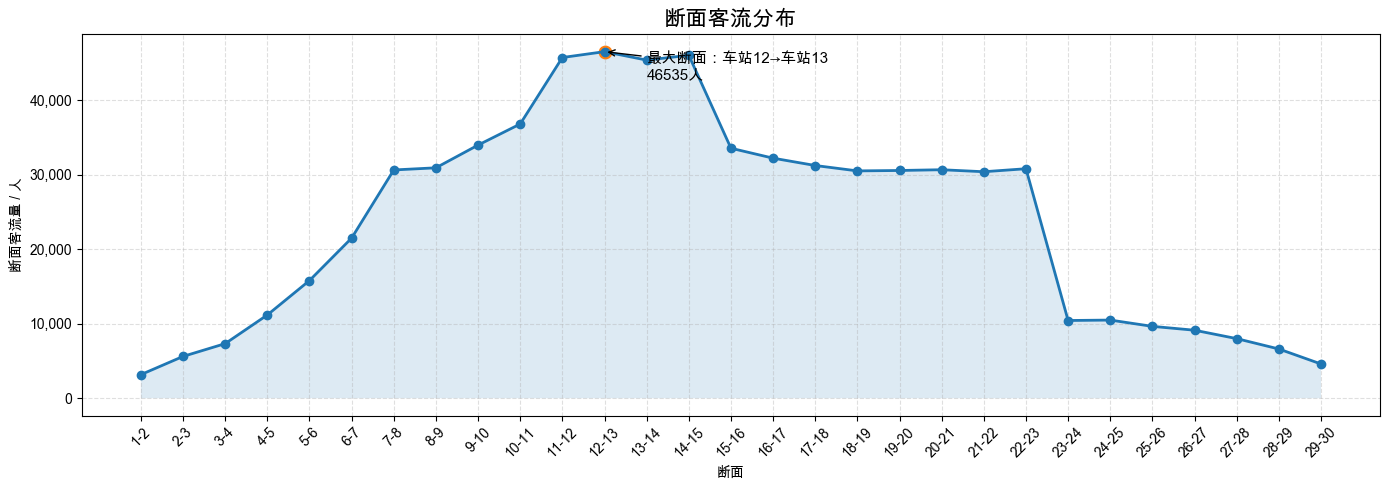

已保存：./output/figures/图1_断面客流分布.png


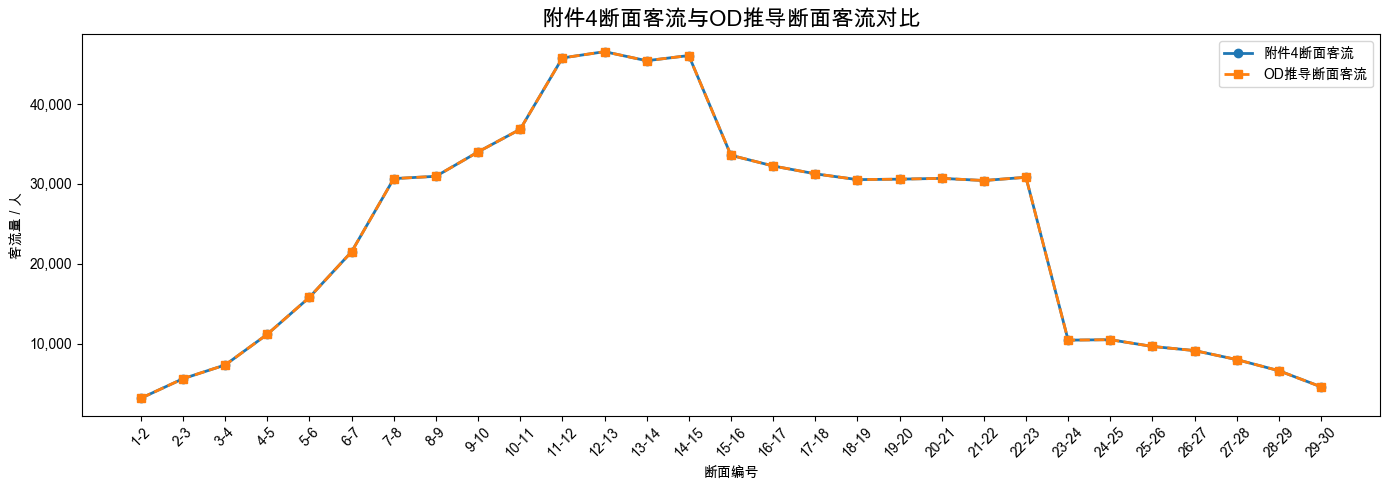

已保存：./output/figures/图2_OD推导断面客流对比.png


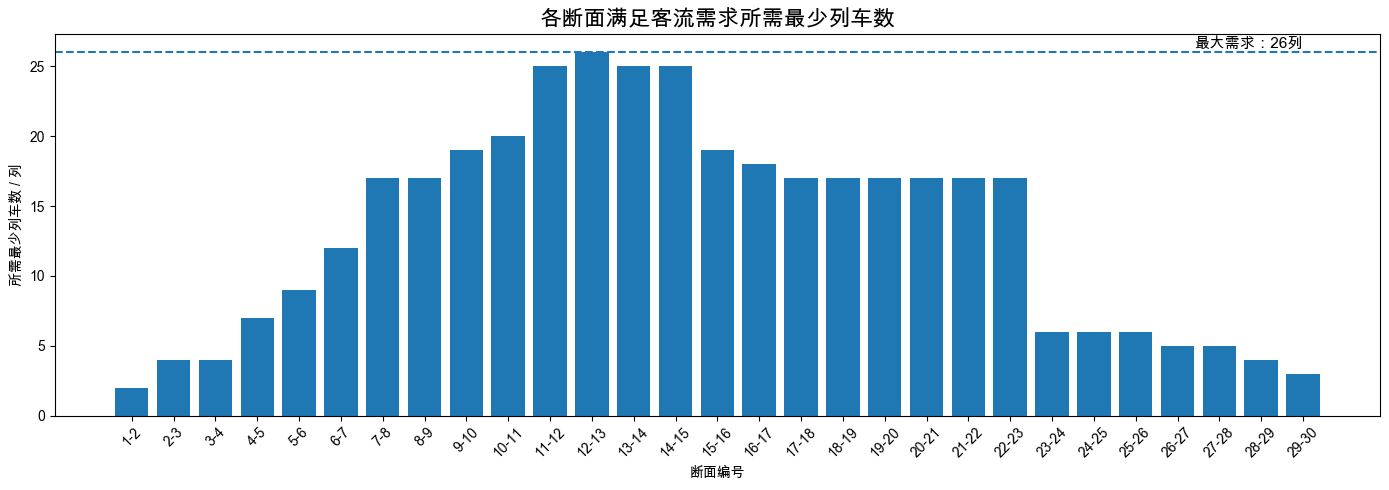

已保存：./output/figures/图3_各断面所需最少列车数.png


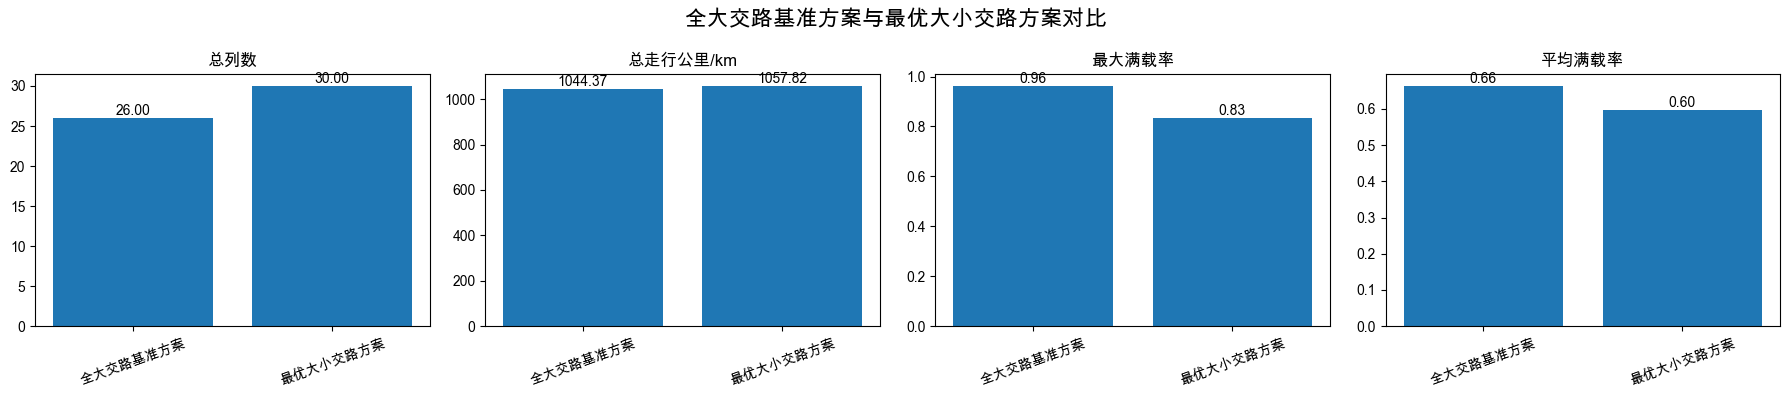

已保存：./output/figures/图4_基准方案与最优方案对比.png


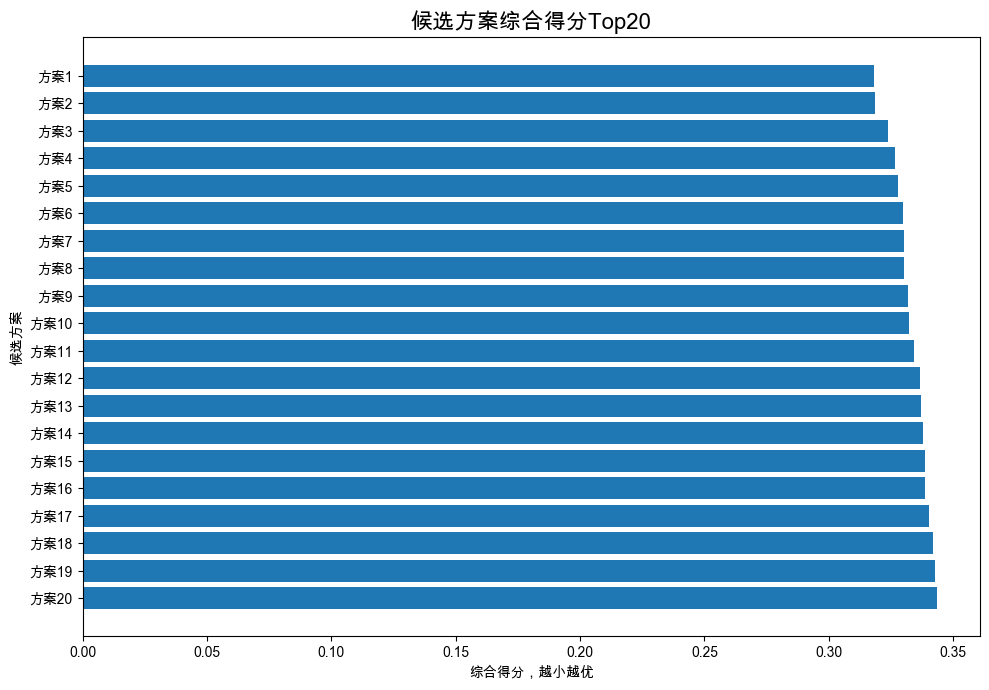

已保存：./output/figures/图5_候选方案综合得分Top20.png


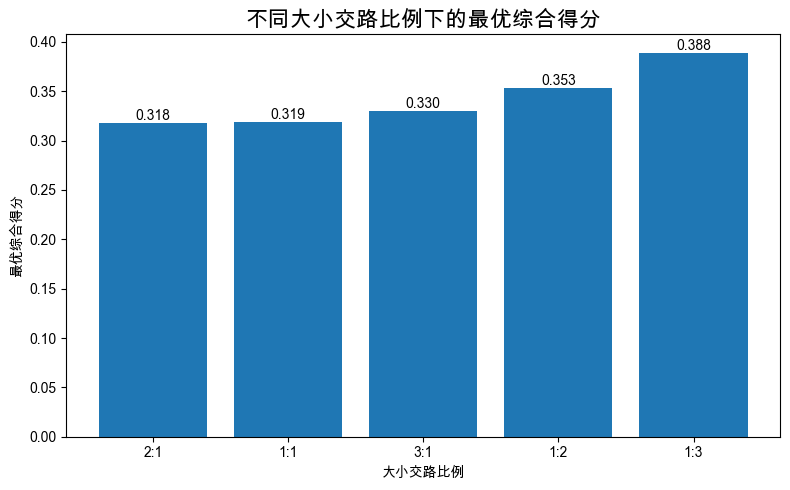

已保存：./output/figures/图6_不同大小交路比例最优得分.png


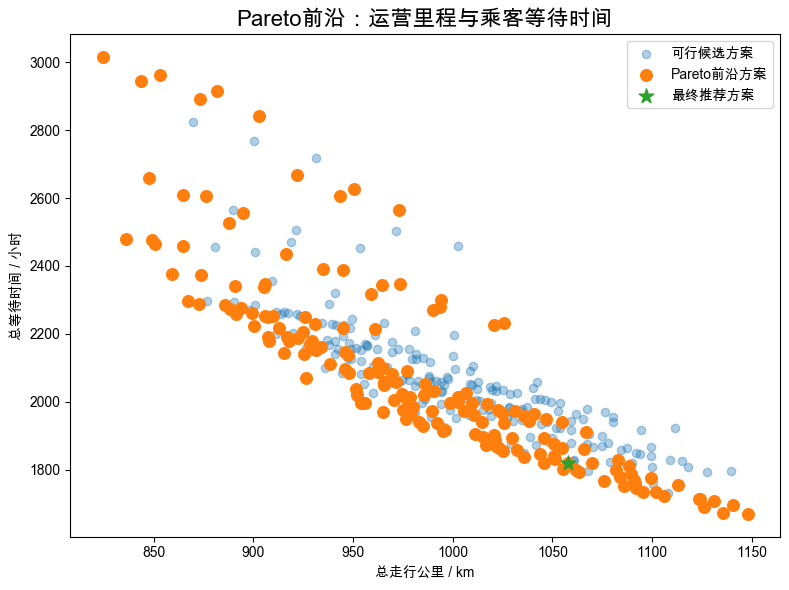

已保存：./output/figures/图7_Pareto前沿_走行公里_vs_等待时间.png


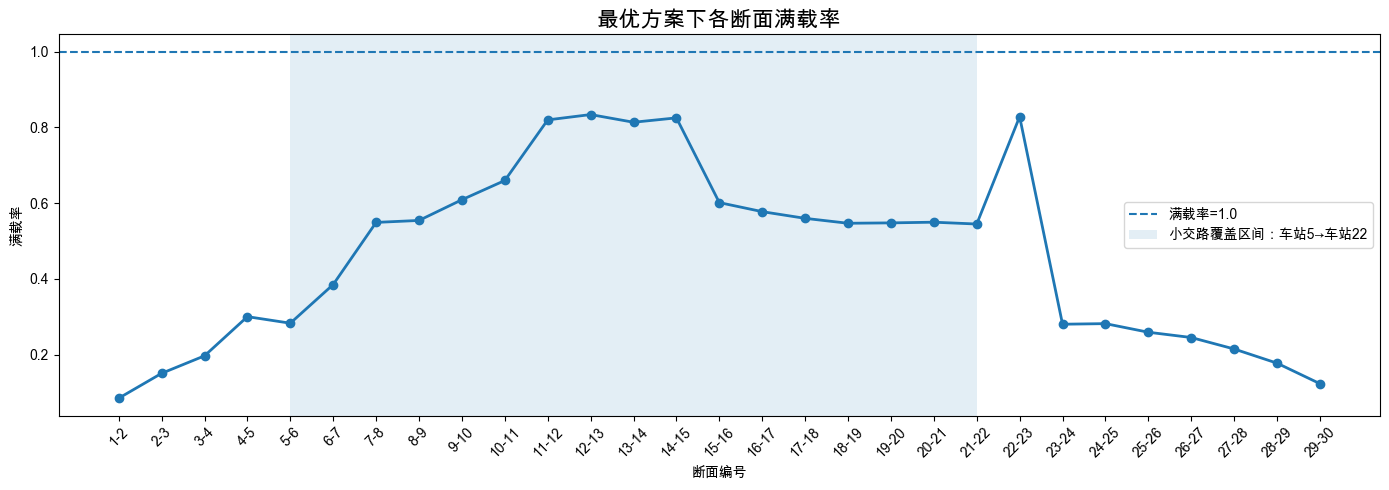

已保存：./output/figures/图8_最优方案断面满载率.png


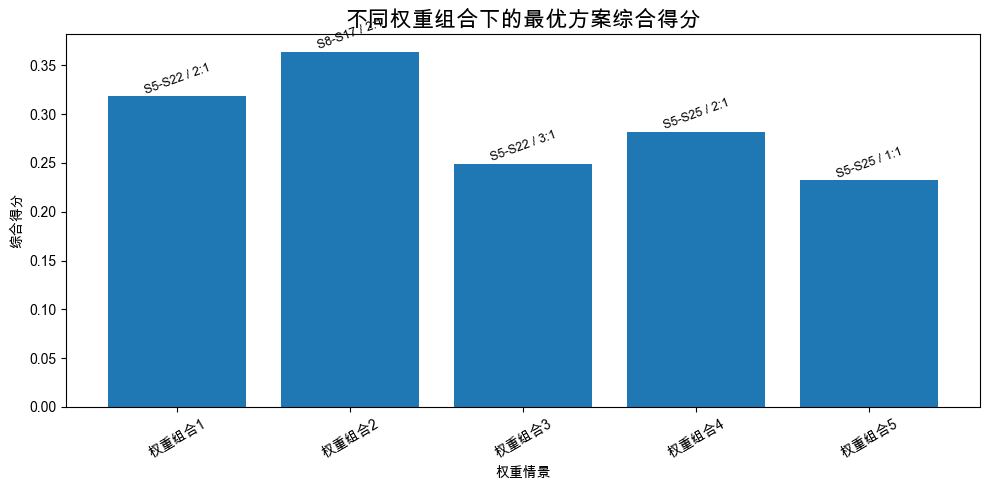

已保存：./output/figures/图9_权重灵敏度分析.png


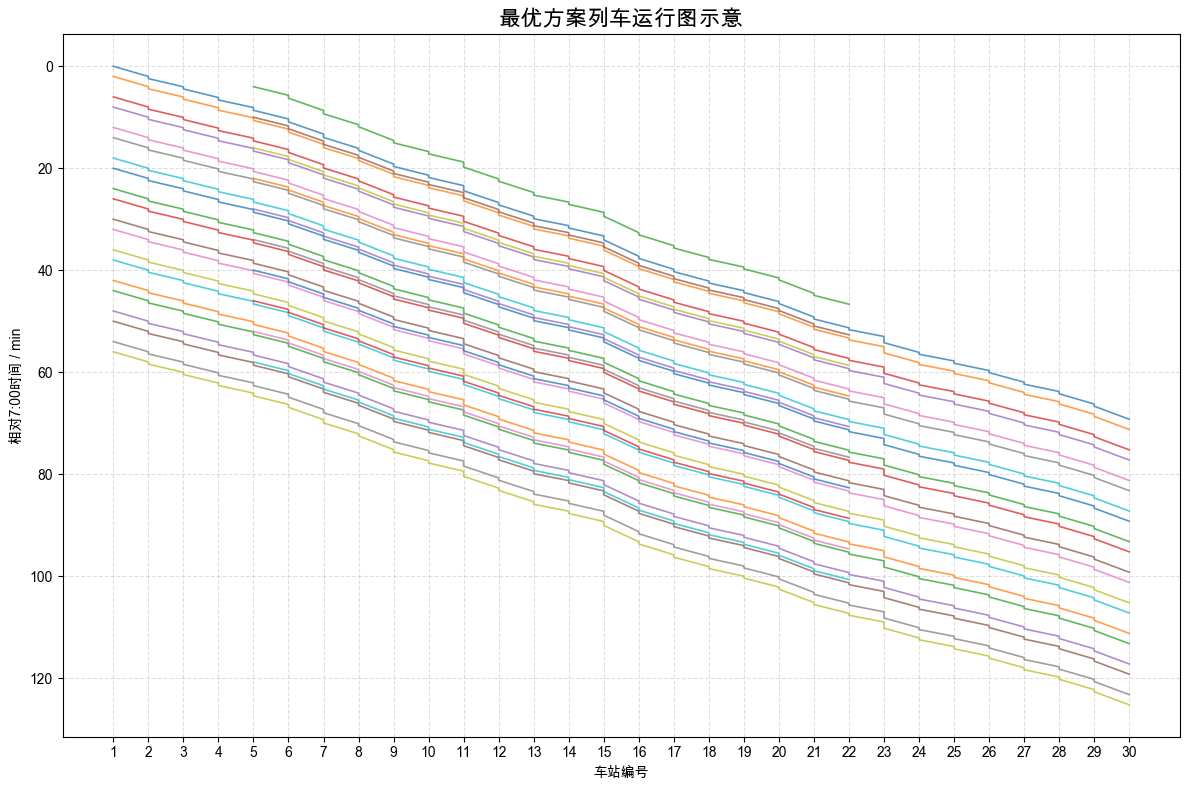

已保存：./output/figures/图10_最优运行图示意.png


In [12]:
# ============================================================
# 9. 论文结果可视化图表
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import numpy as np
import pandas as pd

# 中文字体设置
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "Microsoft YaHei", "PingFang SC"]
plt.rcParams["axes.unicode_minus"] = False

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)


def save_and_show(fig, filename):
    """保存并显示图片。"""
    path = os.path.join(FIG_DIR, filename)
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"已保存：{path}")


# ============================================================
# 图1：断面客流分布图
# ============================================================

def plot_section_flow(section_flow):
    x = np.arange(1, len(section_flow) + 1)
    labels = [f"{i}-{i+1}" for i in x]

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(x, section_flow, marker="o", linewidth=2)
    ax.fill_between(x, section_flow, alpha=0.15)

    max_idx = int(np.argmax(section_flow))
    ax.scatter(x[max_idx], section_flow[max_idx], s=80)
    ax.annotate(
        f"最大断面：车站{x[max_idx]}→车站{x[max_idx]+1}\n{section_flow[max_idx]:.0f}人",
        xy=(x[max_idx], section_flow[max_idx]),
        xytext=(x[max_idx] + 1, section_flow[max_idx] * 0.92),
        arrowprops=dict(arrowstyle="->"),
        fontsize=11
    )

    ax.set_title("断面客流分布", fontsize=16)
    ax.set_xlabel("断面")
    ax.set_ylabel("断面客流量 / 人")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

    save_and_show(fig, "图1_断面客流分布.png")


plot_section_flow(section_flow_file)


# ============================================================
# 图2：OD推导断面客流 vs 附件4断面客流
# ============================================================

def plot_section_flow_compare(section_flow_file, section_flow_od):
    x = np.arange(1, len(section_flow_file) + 1)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(x, section_flow_file, marker="o", linewidth=2, label="附件4断面客流")
    ax.plot(x, section_flow_od, marker="s", linewidth=2, linestyle="--", label="OD推导断面客流")

    ax.set_title("附件4断面客流与OD推导断面客流对比", fontsize=16)
    ax.set_xlabel("断面编号")
    ax.set_ylabel("客流量 / 人")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}-{i+1}" for i in x], rotation=45)
    # ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

    save_and_show(fig, "图2_OD推导断面客流对比.png")


plot_section_flow_compare(section_flow_file, section_flow_od)


# ============================================================
# 图3：各断面所需最少列车数
# ============================================================

def plot_required_trains(section_flow, params):
    required = np.ceil(section_flow / params.capacity).astype(int)
    x = np.arange(1, len(required) + 1)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.bar(x, required)
    ax.axhline(required.max(), linestyle="--", linewidth=1.5)
    ax.text(
        x[-1],
        required.max() + 0.3,
        f"最大需求：{required.max()}列",
        ha="right",
        fontsize=11
    )

    ax.set_title("各断面满足客流需求所需最少列车数", fontsize=16)
    ax.set_xlabel("断面编号")
    ax.set_ylabel("所需最少列车数 / 列")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}-{i+1}" for i in x], rotation=45)
    # ax.grid(axis="y", linestyle="--", alpha=0.4)

    save_and_show(fig, "图3_各断面所需最少列车数.png")


plot_required_trains(section_flow_file, params)


# ============================================================
# 图4：全大交路基准方案 vs 最优大小交路方案
# ============================================================

def plot_baseline_compare(baseline_compare):
    metrics = ["总列数", "总走行公里/km", "最大满载率", "平均满载率"]

    fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))

    for ax, metric in zip(axes, metrics):
        ax.bar(baseline_compare["方案"], baseline_compare[metric])
        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=20)
        # ax.grid(axis="y", linestyle="--", alpha=0.4)

        for i, v in enumerate(baseline_compare[metric]):
            ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

    fig.suptitle("全大交路基准方案与最优大小交路方案对比", fontsize=16)

    save_and_show(fig, "图4_基准方案与最优方案对比.png")


plot_baseline_compare(baseline_compare)


# ============================================================
# 图5：候选方案综合得分Top20
# ============================================================

def plot_top_candidate_scores(candidates, top_n=20):
    top = candidates.head(top_n).copy()
    top["方案编号"] = [f"方案{i+1}" for i in range(len(top))]

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.barh(top["方案编号"][::-1], top["综合得分"][::-1])
    ax.set_title(f"候选方案综合得分Top{top_n}", fontsize=16)
    ax.set_xlabel("综合得分，越小越优")
    ax.set_ylabel("候选方案")
    # ax.grid(axis="x", linestyle="--", alpha=0.4)

    save_and_show(fig, "图5_候选方案综合得分Top20.png")


plot_top_candidate_scores(candidates, top_n=20)


# ============================================================
# 图6：不同大小交路比例下的最优得分
# ============================================================

def plot_ratio_best_score(candidates):
    ratio_best = (
        candidates
        .groupby("比例", as_index=False)
        .agg({
            "综合得分": "min",
            "总走行公里/km": "min",
            "最大满载率": "min"
        })
        .sort_values("综合得分")
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(ratio_best["比例"], ratio_best["综合得分"])
    ax.set_title("不同大小交路比例下的最优综合得分", fontsize=16)
    ax.set_xlabel("大小交路比例")
    ax.set_ylabel("最优综合得分")
    # ax.grid(axis="y", linestyle="--", alpha=0.4)

    for i, v in enumerate(ratio_best["综合得分"]):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=10)

    save_and_show(fig, "图6_不同大小交路比例最优得分.png")


plot_ratio_best_score(candidates)


# ============================================================
# 图7：Pareto前沿散点图：总走行公里 vs 总等待时间
# ============================================================

def plot_pareto_km_wait(candidates, pareto_df):
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        candidates["总走行公里/km"],
        candidates["总等待时间/s"] / 3600,
        alpha=0.35,
        label="可行候选方案"
    )

    ax.scatter(
        pareto_df["总走行公里/km"],
        pareto_df["总等待时间/s"] / 3600,
        s=70,
        label="Pareto前沿方案"
    )

    ax.scatter(
        best["总走行公里/km"],
        best["总等待时间/s"] / 3600,
        s=120,
        marker="*",
        label="最终推荐方案"
    )

    ax.set_title("Pareto前沿：运营里程与乘客等待时间", fontsize=16)
    ax.set_xlabel("总走行公里 / km")
    ax.set_ylabel("总等待时间 / 小时")
    # ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

    save_and_show(fig, "图7_Pareto前沿_走行公里_vs_等待时间.png")


plot_pareto_km_wait(candidates, pareto_df)


# ============================================================
# 图8：最优方案断面满载率
# ============================================================

def plot_best_plan_load(best, section_flow, params):
    n = len(section_flow)
    a = int(best["小交路起点"])
    b = int(best["小交路终点"])
    NL = int(best["大交路数量"])
    NS = int(best["小交路数量"])

    supply_trains = np.array([
        NL + NS if a <= k < b else NL
        for k in range(1, n + 1)
    ])

    supply_cap = supply_trains * params.capacity
    load_rate = section_flow / supply_cap

    x = np.arange(1, n + 1)

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(x, load_rate, marker="o", linewidth=2)
    ax.axhline(1.0, linestyle="--", linewidth=1.5, label="满载率=1.0")
    ax.axvspan(a, b - 1, alpha=0.12, label=f"小交路覆盖区间：车站{a}→车站{b}")

    ax.set_title("最优方案下各断面满载率", fontsize=16)
    ax.set_xlabel("断面编号")
    ax.set_ylabel("满载率")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}-{i+1}" for i in x], rotation=45)
    # ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

    save_and_show(fig, "图8_最优方案断面满载率.png")


plot_best_plan_load(best, section_flow_file, params)


# ============================================================
# 图9：权重灵敏度分析结果
# ============================================================

def plot_sensitivity_result(sensitivity_df):
    df = sensitivity_df.copy()
    df["推荐方案"] = (
        "S" + df["小交路起点"].astype(str)
        + "-S" + df["小交路终点"].astype(str)
        + " / " + df["比例"].astype(str)
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(df["情景"], df["综合得分"])
    ax.set_title("不同权重组合下的最优方案综合得分", fontsize=16)
    ax.set_xlabel("权重情景")
    ax.set_ylabel("综合得分")
    ax.tick_params(axis="x", rotation=30)
    # ax.grid(axis="y", linestyle="--", alpha=0.4)

    for i, row in df.iterrows():
        ax.text(
            i,
            row["综合得分"],
            row["推荐方案"],
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=20
        )

    save_and_show(fig, "图9_权重灵敏度分析.png")


plot_sensitivity_result(sensitivity_df)


# ============================================================
# 图10：最优运行图示意图
# ============================================================

def plot_timetable_diagram(timetable: pd.DataFrame, max_trains: int = 30):
    """
    根据 problem2_timetable 格式绘制运行图示意。
    横轴为车站，纵轴为时间。
    """
    def hms_to_seconds(x):
        if pd.isna(x) or x == "":
            return np.nan
        h, m, s = map(int, str(x).split(":"))
        return h * 3600 + m * 60 + s

    station_rows = timetable.iloc[:, 0].astype(str).tolist()
    train_cols = timetable.columns[1:max_trains + 1]

    fig, ax = plt.subplots(figsize=(12, 8))

    for col in train_cols:
        xs = []
        ys = []

        for idx, label in enumerate(station_rows):
            value = timetable.loc[idx, col]
            if pd.isna(value) or value == "":
                continue

            station = int(re.search(r"车站(\d+)", label).group(1))
            sec = hms_to_seconds(value)

            xs.append(station)
            ys.append((sec - params.start_seconds) / 60)

        if len(xs) >= 2:
            ax.plot(xs, ys, linewidth=1.2, alpha=0.75)

    ax.set_title("最优方案列车运行图示意", fontsize=16)
    ax.set_xlabel("车站编号")
    ax.set_ylabel("相对7:00时间 / min")
    ax.set_xticks(range(1, 31))
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.invert_yaxis()

    save_and_show(fig, "图10_最优运行图示意.png")


plot_timetable_diagram(timetable, max_trains=int(best["总列数"]))

## 9. 论文写作提示

可在论文中将模型结果组织为：

1. **数据预处理与客流特征分析**：说明断面客流呈现中部高、两端低的分布特征；
2. **问题一模型**：说明候选小交路区间由可折返站集合枚举，开行数量由断面运力约束筛选；
3. **问题二模型**：说明运行图由等间隔发车和区间运行时间递推生成；
4. **问题三分析**：用全大交路基准方案、最优方案、灵敏度分析和 Pareto 前沿进行量化支撑；
5. **模型评价**：说明当前车辆需求模型为单向占用近似，若题目进一步提供折返时间和周转时间，可拓展为完整周转模型。